# 🤖 Machine Learning: Simple Linear Regression

## 📌 Quick Overview
This lab focuses on implementing **Simple Linear Regression** from scratch using `scikit-learn`. The objective is to build a predictive model that estimates vehicle $CO_2$ emissions based on fuel consumption data.

---

## 🎯 My Goals
- [ ] Understand and implement Simple Linear Regression using `scikit-learn`.
- [ ] Split dataset into Train/Test sets, train the model, and evaluate its accuracy.

---

## 🛠️ Tech Stack & Tools
* 🐼 **Pandas:** For data loading and manipulation.
* 🔢 **NumPy:** For handling multi-dimensional arrays and mathematical operations.
* 📊 **Matplotlib:** For plotting data distributions and regression lines.
* 🧠 **Scikit-learn (sklearn):** For building and training the Machine Learning model.

In [209]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Enable inline plotting to display matplotlib graphs directly below the code cells
%matplotlib inline

# Dataset URL from the IBM Skills Network cloud storage
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

# Load the CSV data into a structured Pandas DataFrame
df = pd.read_csv(dataset_url)

# Display a random sample of 5 rows to verify the data loaded correctly
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
897,2014,PORSCHE,CAYMAN,TWO-SEATER,2.7,6,AM7,Z,10.7,7.4,9.2,31,212
858,2014,NISSAN,SENTRA,MID-SIZE,1.8,4,M6,X,8.7,6.6,7.8,36,179
769,2014,MERCEDES-BENZ,S 63 AMG 4MATIC,FULL-SIZE,5.5,8,AS7,Z,15.6,10.3,13.2,21,304
940,2014,SRT,VIPER COUPE,TWO-SEATER,8.4,10,M6,Z,20.0,13.0,16.9,17,389
310,2014,DODGE,CHARGER FFV,FULL-SIZE,3.6,6,A5,E,18.3,12.6,15.7,18,251


# 🔍 Understanding the Data

Before training our model, let's understand what each column (feature) in the `FuelConsumption.csv` dataset represents. This dataset contains specific fuel consumption ratings and estimated Carbon Dioxide ($CO_2$) emissions for new light-duty vehicles retail-sold in Canada.

---

## 📋 Data Dictionary (Features Explained)

| Column Name | Description & Example |
| :--- | :--- |
| **MODEL YEAR** | The manufacturing year of the vehicle (e.g., 2014). |
| **MAKE** | The manufacturer/brand of the car (e.g., VOLVO, TOYOTA). |
| **MODEL** | The specific model of the vehicle (e.g., S60 AWD). |
| **VEHICLE CLASS** | The class/size category of the vehicle (e.g., COMPACT, SUV). |
| **ENGINE SIZE** | The engine displacement volume in liters (e.g., 3.0). |
| **CYLINDERS** | Number of cylinders in the engine (e.g., 6). |
| **TRANSMISSION** | The type of transmission/gearbox used (e.g., AS6). |
| **FUEL TYPE** | The type of fuel required (e.g., Z = Premium gasoline, X = Regular). |
| **FUEL CONSUMPTION inside CITY** | Fuel efficiency inside the city, measured in Liters per 100 km (L/100 km). |
| **FUEL CONSUMPTION on HWY** | Fuel efficiency on highways, measured in Liters per 100 km (L/100 km). |
| **FUEL CONSUMPTION COMBINED** | The weighted average of City and Highway fuel consumption (L/100 km). |
| **FUEL CONSUMPTION COMBINED MPG** | Fuel consumption measured in Miles Per Gallon (MPG). |
| **$CO_2$ EMISSIONS** | The amount of carbon dioxide emitted per kilometer, in grams (g/km) -- **Our Target Variable**. |

---




# 📈  Data Exploration (Statistical Summary)

Now, we will explore the dataset to understand its distribution and check for any anomalies or patterns using descriptive statistics.

---

##  Running `df.describe()`
The `df.describe()` method generates a statistical summary of all numerical columns in the DataFrame. It calculates key metrics such as:
* **`count`:** Total number of non-null values.
* **`mean`:** The average value.
* **`std`:** Standard deviation (how spread out the data is).
* **`min` / `max`:** The lowest and highest values in the column.
* **`25%`, `50%`, `75%`:** Percentile values (Median is the 50% mark).

In [210]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


# 🎯  Selecting Features

Not all data columns are useful for predicting $CO_2$ emissions. To simplify our model, we will select only the features that have a strong relationship with $CO_2$ emissions.

---

## 🛠️ Feature Selection
We create a new DataFrame named `cdf` by extracting only the most relevant columns from our main dataset (`df`).

* **Selected Features:**
  1. `ENGINESIZE` - Engine displacement volume in liters.
  2. `CYLINDERS` - Number of cylinders.
  3. `FUELCONSUMPTION_COMB` - Combined fuel consumption (City + Highway) in L/100 km.
  4. `CO2EMISSIONS` - Carbon dioxide emissions in grams per kilometer (**Target Variable**).

In [211]:
# Create a sub-dataset containing only the features selected for the regression model
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]

# Display the first 9 rows of the filtered dataset to verify the changes
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


# 📊 Data Visualization (Histograms)

To better understand the distribution of our selected features, we can plot a **Histogram** for each column. A histogram shows the frequency of data points within specified ranges.

---

## 🛠️ Code Explanation

* **`cdf.hist()`**: This Pandas method automatically generates individual histograms for all numerical columns inside our filtered DataFrame (`cdf`).
* **`figsize=(12, 8)`**: Adjusts the width and height of the overall plotting area to make graphs clear.
* **`plt.show()`**: This command from the `matplotlib` library renders and displays the plots clearly on the screen.

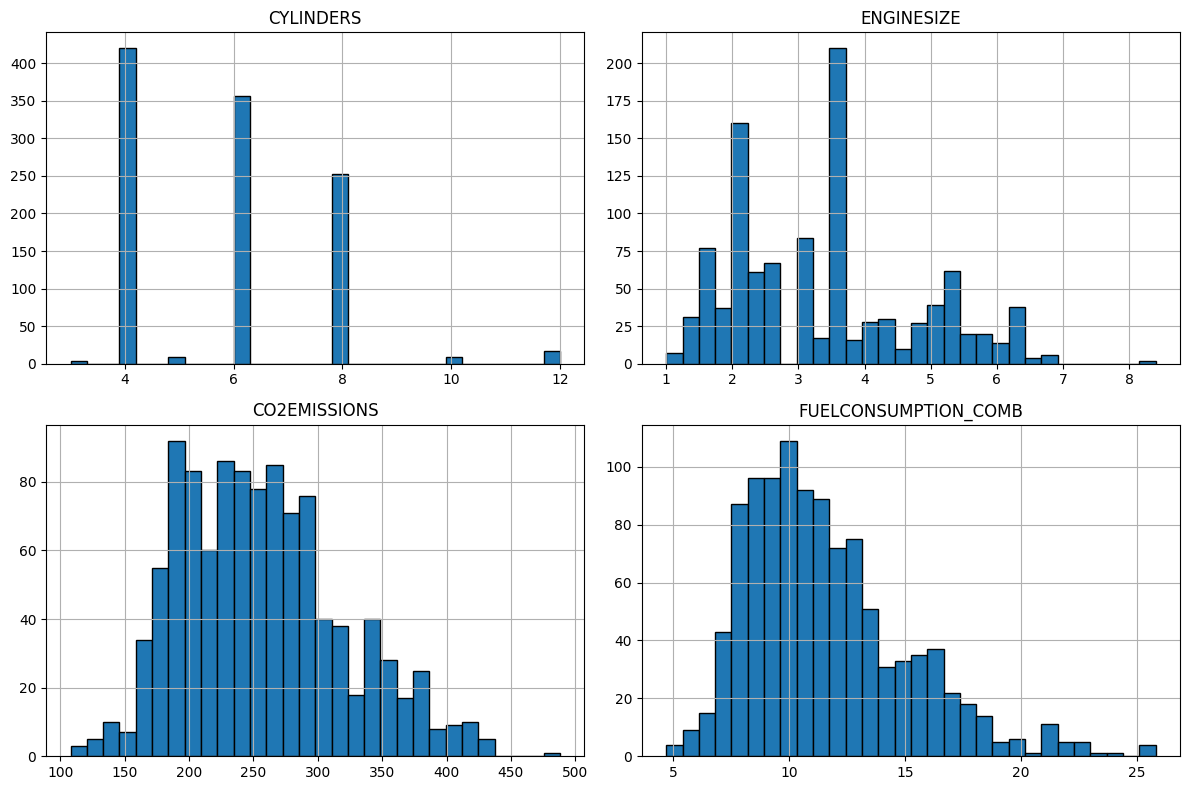

In [212]:
# Select the features to plot
viz = cdf[['CYLINDERS', 'ENGINESIZE', 'CO2EMISSIONS', 'FUELCONSUMPTION_COMB']]

# Plot histograms for each feature with a clean layout
viz.hist(figsize=(12, 8), bins=30, edgecolor='black')

# Render the plots
plt.tight_layout()
plt.show()

# 📈  Visualizing Linear Relationships (Scatter Plots)

Based on our previous histogram analysis, we observed that combined fuel consumption and $CO_2$ emissions share very similar distributions. 

To implement **Simple Linear Regression**, we must visually confirm that a **Linear Relationship** exists between these features. We use a Scatter Plot to graph `FUELCONSUMPTION_COMB` against `CO2EMISSIONS`.

---

## 🛠️ Code Breakdown

* **`plt.scatter(X, Y, color)`**: Plots data points as individual dots on a 2D plane. We map Fuel Consumption to the X-axis and $CO_2$ Emissions to the Y-axis.
* **`plt.xlabel()` & `plt.ylabel()`**: Adds descriptive labels to the horizontal ($X$) and vertical ($Y$) axes so the graph is easy to read.
* **`plt.grid(True)`**: Adds a subtle background grid to make it easier to see exact data points.
* **`plt.show()`**: Renders and displays the final chart inside the notebook.

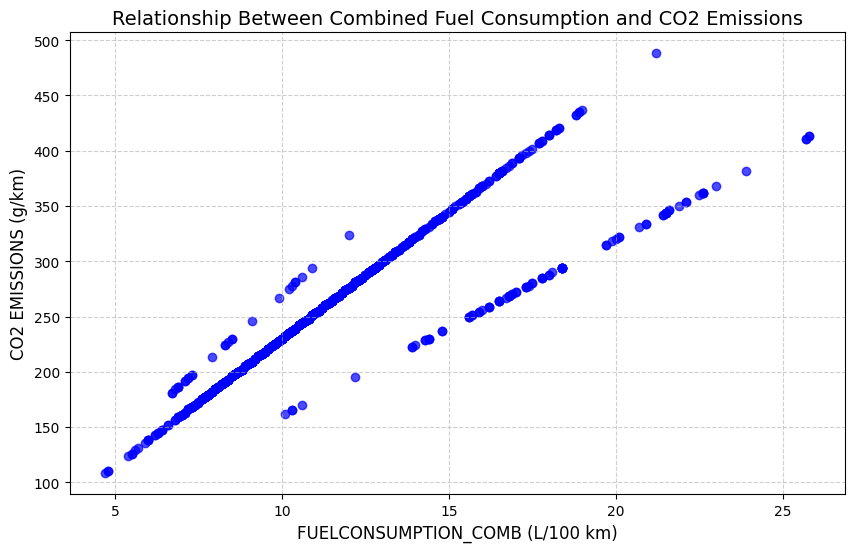

In [213]:
# Set the figure size for clarity
plt.figure(figsize=(10, 6))

# Plotting the relationship using a Scatter Plot
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue', alpha=0.7)

# Adding titles and axis labels
plt.title("Relationship Between Combined Fuel Consumption and CO2 Emissions", fontsize=14)
plt.xlabel("FUELCONSUMPTION_COMB (L/100 km)", fontsize=12)
plt.ylabel("CO2 EMISSIONS (g/km)", fontsize=12)

# Enable grid lines for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# 📊  Visualizing Engine Size vs. $CO_2$ Emissions

Now, we plot a scatter plot for `ENGINESIZE` against `CO2EMISSIONS` to visually inspect how the physical size of the engine affects carbon emissions.

---

## 🛠️ Code Breakdown

* **`plt.scatter()`**: Plots Engine Size on the horizontal ($X$) axis and $CO_2$ Emissions on the vertical ($Y$) axis using blue dots.
* **`plt.xlabel()` & `plt.ylabel()`**: Sets descriptive labels for both axes to maintain proper formatting.

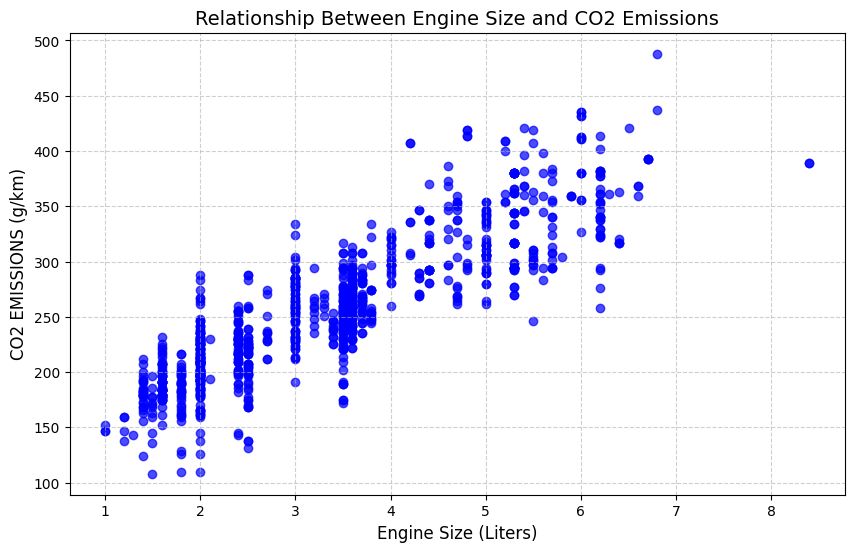

In [214]:
# Set the figure size for consistency
plt.figure(figsize=(10, 6))

# Plotting Engine Size vs Emissions
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue', alpha=0.7)

# Adding labels and title
plt.title("Relationship Between Engine Size and CO2 Emissions", fontsize=14)
plt.xlabel("Engine Size (Liters)", fontsize=12)
plt.ylabel("CO2 EMISSIONS (g/km)", fontsize=12)

# Enable grid lines
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# 📊  Visualizing Cylinders vs. $CO_2$ Emissions

To complete our feature exploration, we will visualize the relationship between the number of engine **`CYLINDERS`** and **`CO2EMISSIONS`** using a scatter plot to evaluate their linearity.

---

## 🛠️ Code Breakdown

* **`plt.scatter()`**: Plots the number of Cylinders on the horizontal ($X$) axis and $CO_2$ Emissions on the vertical ($Y$) axis.
* **`fontsize=12`**: Standardizes the text size for labels to maintain consistent formatting across all visualizations.

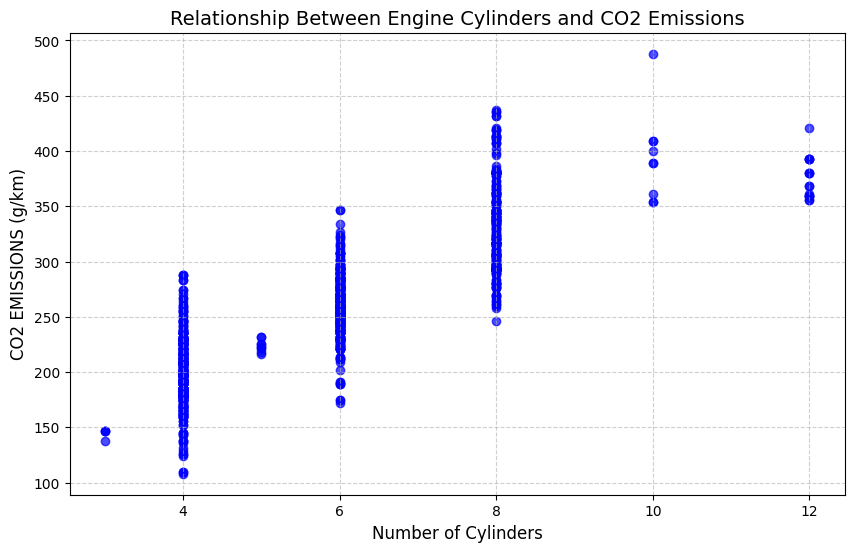

In [215]:
# Set the figure size for consistency
plt.figure(figsize=(10, 6))

# Plotting Cylinders against CO2 Emissions
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue', alpha=0.7)

# Adding labels and title
plt.title("Relationship Between Engine Cylinders and CO2 Emissions", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("CO2 EMISSIONS (g/km)", fontsize=12)

# Enable grid lines
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# 🎯Extracting Input Features ($X$) and Target Labels ($y$)

To train a Machine Learning model, we need to separate our dataset into two main components: the input that the model learns from, and the output that the model tries to predict.

---

## 🧠 Key ML Concepts: Features vs. Labels

1. **Independent Variable ($X$):** The input feature used to make a prediction. For this lab, we are using **`ENGINESIZE`**. (Note: Capital $X$ is used because `scikit-learn` expects a 2D matrix of features `[samples, features]`).
2. **Dependent Variable ($y$):** The target output or label we want to predict. Here, it is **`CO2EMISSIONS`**. (Note: Lowercase $y$ is used because it is a 1D vector/column).

---

## 🛠️ Code Breakdown

* **`cdf[['ENGINESIZE']]`**: Using double square brackets ensures that the input $X$ is extracted as a 2D structure, which matches the required input shape for `scikit-learn`.
* **`.to_numpy()`**: Converts the Pandas data into a raw **NumPy Array** for high-performance mathematical computations during training.

In [216]:
# Extracting the input feature (Engine Size) as a 2D NumPy array
X = cdf[['ENGINESIZE']].to_numpy()

# Extracting the target output (CO2 Emissions) as a 1D NumPy array
y = cdf['CO2EMISSIONS'].to_numpy()

# Print shapes to verify they are correct for scikit-learn
print(f"Shape of X (Features): {X.shape}")
print(f"Shape of y (Target):   {y.shape}")

Shape of X (Features): (1067, 1)
Shape of y (Target):   (1067,)


# ✂️  Splitting Dataset into Train and Test Sets

To properly evaluate our Machine Learning model, we need to test it on data it has never seen before. If we test the model using the same data it learned from, it might just memorize the answers (**overfitting**) instead of actually learning the underlying patterns.

---

## 📊 Evaluation Strategy: Out-of-Sample Accuracy

We split our extracted features ($X$) and labels ($y$) into two mutually exclusive sets:
1. **Training Set ($80\%$):** Used to train our Simple Linear Regression model so it can learn the relationship between Engine Size and $CO_2$ emissions.
2. **Testing Set ($20\%$):** Kept hidden from the model during training. It acts as an "unseen" exam paper to evaluate the model's real-world predictive accuracy.

*Note: A 20% to 30% split for testing is standard practice. Larger training sets prevent the model from picking up fake or spurious patterns, especially in smaller datasets.*

---

## 🛠️ Code Breakdown

We use the `train_test_split` function from the `scikit-learn` library to automate this process.

* **`test_size=0.2`**: Allocates exactly 20% of the data for testing and 80% for training.
* **`random_state=42`**: Sets a seed for the random number generator. This ensures that the dataset is shuffled in the exact same way every time you run the code, making your results reproducible.

In [217]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to confirm the split was successful
print(f"Total rows in X: {X.shape[0]} -> Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Total rows in y: {y.shape[0]} -> Train: {y_train.shape[0]} | Test: {y_test.shape[0]}")

Total rows in X: 1067 -> Train: 853 | Test: 214
Total rows in y: 1067 -> Train: 853 | Test: 214


# 🔍 Checking Data Types and Shapes (Vectors)

After splitting our dataset, it is a good practice to inspect the dimensions and types of our newly created training variables to ensure they are formatted correctly for `scikit-learn`.

---

## 🛠️ Code Breakdown

We use Python's built-in `type()` function alongside NumPy's `.shape` attribute to inspect our variables:
* **`type(X_train)`**: Verifies the structural format of the data. Since we used `.to_numpy()`, this will return `<class 'numpy.ndarray'>`.
* **`X_train.shape`**: Returns the exact dimensions (rows, columns) of the array to ensure the shape matches the 2D requirement for $X$ and 1D for $y$.

In [218]:
import numpy as np

# Print the data type of the split arrays
print(f"Data Type of X_train: {type(X_train)}")
print(f"Data Type of y_train: {type(y_train)}")
print("-" * 40)

# Inspecting the exact dimensions (Shapes)
print(f"Dimensions of X_train (2D Matrix): {X_train.shape}")
print(f"Dimensions of y_train (1D Vector): {y_train.shape}")

Data Type of X_train: <class 'numpy.ndarray'>
Data Type of y_train: <class 'numpy.ndarray'>
----------------------------------------
Dimensions of X_train (2D Matrix): (853, 1)
Dimensions of y_train (1D Vector): (853,)


# 🖨️ Printing Test Arrays to Inspect the Values

To visually inspect the actual numbers stored inside our testing variables, we can use Python's `print()` function. This helps us see the exact raw inputs and outputs before making any predictions.

*Note: Python is case-sensitive! Ensure you use Capital `X_test` and lowercase `y_test` to match our previous definitions.*

In [219]:
# Printing the first 5 test features and labels to avoid a massive text dump
print("X_test (First 5 Engine Sizes in Liters):\n", X_test[:5])
print("-" * 50)
print("y_test (First 5 Actual CO2 Emissions in g/km):\n", y_test[:5])

X_test (First 5 Engine Sizes in Liters):
 [[4.7]
 [3.5]
 [3.6]
 [3. ]
 [2. ]]
--------------------------------------------------
y_test (First 5 Actual CO2 Emissions in g/km):
 [304 221 294 221 207]


# 🛠️  Code Deep-Dive: Building and Training the Model

To understand how our model learns, we need to look closer at the model setup, data formatting, and the actual training process. Here is a detailed breakdown of these critical steps:

---

### 1️⃣ Creating the Model Object
Before training, we must initialize a blank Linear Regression model predictor object from the `scikit-learn` library. This object acts as our empty machine learning brain.

### 2️⃣ Training the Model (`.fit()`)
We feed our training features (`X_train`) and training labels (`y_train`) into the model using the `.fit()` method. This is where the actual "learning" happens. The mathematical equation it solves is:
$$y = \theta_0 + \theta_1 x$$

Where:
* $\theta_1$ is the **Coefficient / Slope** (how much $CO_2$ increases per liter of engine size).
* $\theta_0$ is the **Intercept** (the baseline $CO_2$ emission when engine size is 0).

In [220]:
from sklearn import linear_model

# 1. Create a blank linear regression model object
regressor = linear_model.LinearRegression()

# 2. Train the model using the training sets
regressor.fit(X_train, y_train)

# 3. Extract and print the calculated Slope (Coefficient) and Intercept
print("🎉 Model Training Completed Successfully!")
print("-" * 45)
print(f"Calculated Coefficient (Slope - 𝜃1): {regressor.coef_[0]:.4f}")
print(f"Calculated Intercept (𝜃0):          {regressor.intercept_:.4f}")

🎉 Model Training Completed Successfully!
---------------------------------------------
Calculated Coefficient (Slope - 𝜃1): 38.9930
Calculated Intercept (𝜃0):          126.2897


# 📊  Visualizing Model Outputs (Goodness-of-Fit)

After training our model and extracting the parameters, we can visually evaluate its **Goodness-of-Fit**. We do this by plotting our mathematical regression line directly on top of the actual training data scatter plot.

The straight line generated by our model is defined by the classic linear equation:
$$y = \theta_0 + \theta_1 x$$

---

## 🛠️ Code Breakdown

* **`plt.scatter(X_train, y_train, color='blue')`**: Draws the original training data points as blue dots.
* **`plt.plot(X_train, regressor.predict(X_train), '-r')`**: Plots the continuous linear prediction line. The `'-r'` argument specifies a **solid red line** calculated dynamically using the model's learned parameters.
* **`plt.legend()`**: Adds a small label box on the graph to distinguish between the actual data points and the fitted regression line.

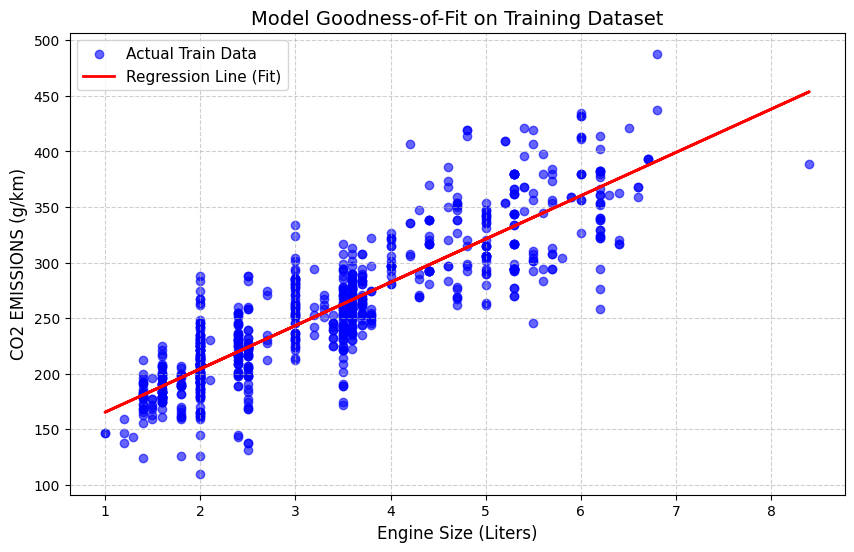

In [221]:
# Set the figure size for consistency
plt.figure(figsize=(10, 6))

# 1. Plot the actual training data points
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label="Actual Train Data")

# 2. Plot the trained regression line
plt.plot(X_train, regressor.predict(X_train), '-r', linewidth=2, label="Regression Line (Fit)")

# Adding labels, title, and legend
plt.title("Model Goodness-of-Fit on Training Dataset", fontsize=14)
plt.xlabel("Engine Size (Liters)", fontsize=12)
plt.ylabel("CO2 EMISSIONS (g/km)", fontsize=12)
plt.legend(fontsize=11, loc="upper left")

# Enable grid lines for better analysis
plt.grid(True, linestyle='--', alpha=0.6)

# Display the final plot
plt.show()

# 📈 Model Evaluation

To determine how well our Simple Linear Regression model generalizes to unseen data, we compare the actual values (`y_test`) with the model's predicted values (`y_pred`). Evaluation metrics quantify our model's accuracy and reveal hidden errors that need improvement.

---

## 📋 Understanding Regression Metrics

1. **Mean Absolute Error (MAE):** The average of the absolute differences between actual values and predicted values. It provides a straightforward measure of how far off our predictions are on average.
2. **Mean Squared Error (MSE):** The average of the squared errors. Because errors are squared, larger mistakes are heavily penalized.
3. **Root Mean Squared Error (RMSE):** The square root of MSE. This converts the error statistic back into the original unit of the target variable ($g/km$ of $CO_2$), making it highly interpretable.
4. **$R^2$-Score (Coefficient of Determination):** A performance score representing how well the regression line fits the data points. 
   * **Best possible score is 1.0** (Perfect prediction).
   * A higher score means the model successfully captures a vast majority of the data's variance.

In [222]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Generate predictions on unseen test data (X_test is already 2D)
y_pred = regressor.predict(X_test)

# 2. Compute and print evaluation metrics using f-strings for cleaner formatting
print("📊 Final Model Evaluation Metrics:")
print("-" * 40)
print(f"Mean Absolute Error (MAE):     {mean_absolute_error(y_test, y_pred):.2f} g/km")
print(f"Mean Squared Error (MSE):      {mean_squared_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} g/km")
print(f"R2-Score (Accuracy):           {r2_score(y_test, y_pred):.2f}")

📊 Final Model Evaluation Metrics:
----------------------------------------
Mean Absolute Error (MAE):     24.10 g/km
Mean Squared Error (MSE):      985.94
Root Mean Squared Error (RMSE): 31.40 g/km
R2-Score (Accuracy):           0.76


# 🏆 Part 18: Final Model Performance Summary

We have successfully trained and evaluated our Simple Linear Regression model. Here are the final performance metrics achieved on the unseen test dataset:

| Evaluation Metric | Score / Value | Interpretation |
| :--- | :--- | :--- |
| **Mean Absolute Error (MAE)** | **24.10** | On average, our model's predictions are off by about 24.10 grams of $CO_2$ per km. |
| **Mean Squared Error (MSE)** | **985.94** | The variance of the residuals; shows a stable error distribution without extreme penalties. |
| **Root Mean Squared Error (RMSE)** | **31.40** | Standard deviation of the residuals, measured in the exact unit ($g/km$). |
| **$R^2$-Score** | **0.76 (76%)** | **Highly Successful!** 76% of the variance in $CO_2$ emissions can be accurately explained by just the car's Engine Size. |

---

### 🎯 Conclusion
An $R^2$-score of **0.76** indicates a strong, highly reliable linear relationship. For a baseline model that relies on a single input feature (`ENGINESIZE`), this is an excellent predictive result!

# 📊  Visualizing Regression Line over Test Data

To visually evaluate how well our model generalizes to completely unseen data, we plot our learned regression model line directly over the **Testing Dataset** (`X_test`, `y_test`) instead of the training dataset.

---

## 🛠️ Code Breakdown

* **`plt.scatter(X_test, y_test, color='blue')`**: Draws the unseen testing data points as blue dots.
* **`plt.plot(X_test, regressor.predict(X_test), '-r')`**: Plots the continuous linear prediction line over the test inputs.
* **`plt.legend()`**: Displays a label box to differentiate between actual test points and the prediction line.

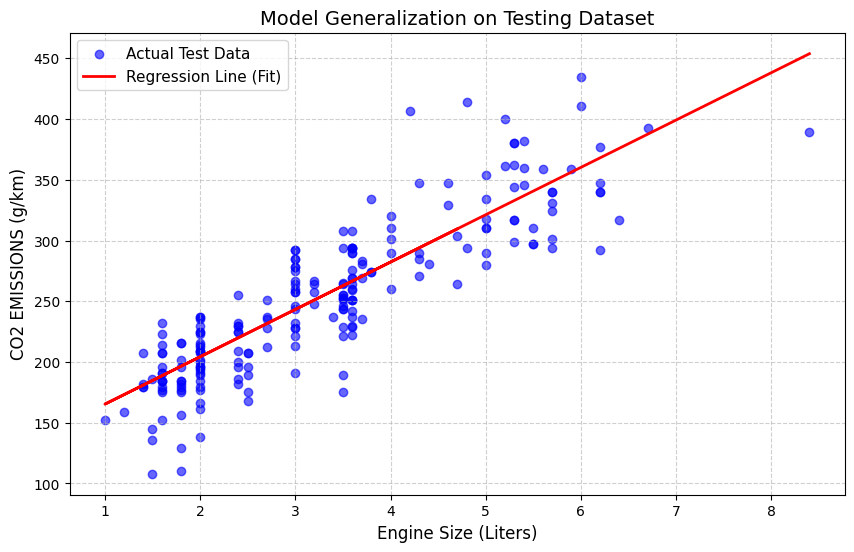

In [223]:
# Set the figure size for consistency
plt.figure(figsize=(10, 6))

# 1. Plot the actual testing data points
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual Test Data')

# 2. Plot the regression line over the test inputs
plt.plot(X_test, regressor.predict(X_test), '-r', linewidth=2, label='Regression Line (Fit)')

# Adding labels, title, and legend
plt.title("Model Generalization on Testing Dataset", fontsize=14)
plt.xlabel("Engine Size (Liters)", fontsize=12)
plt.ylabel("CO2 EMISSIONS (g/km)", fontsize=12)
plt.legend(fontsize=11, loc="upper left")

# Enable grid lines
plt.grid(True, linestyle='--', alpha=0.6)

# Display the final plot
plt.show()